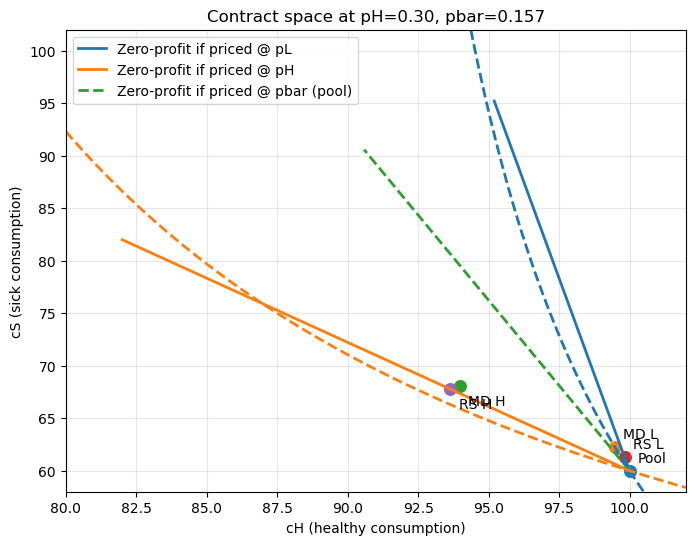

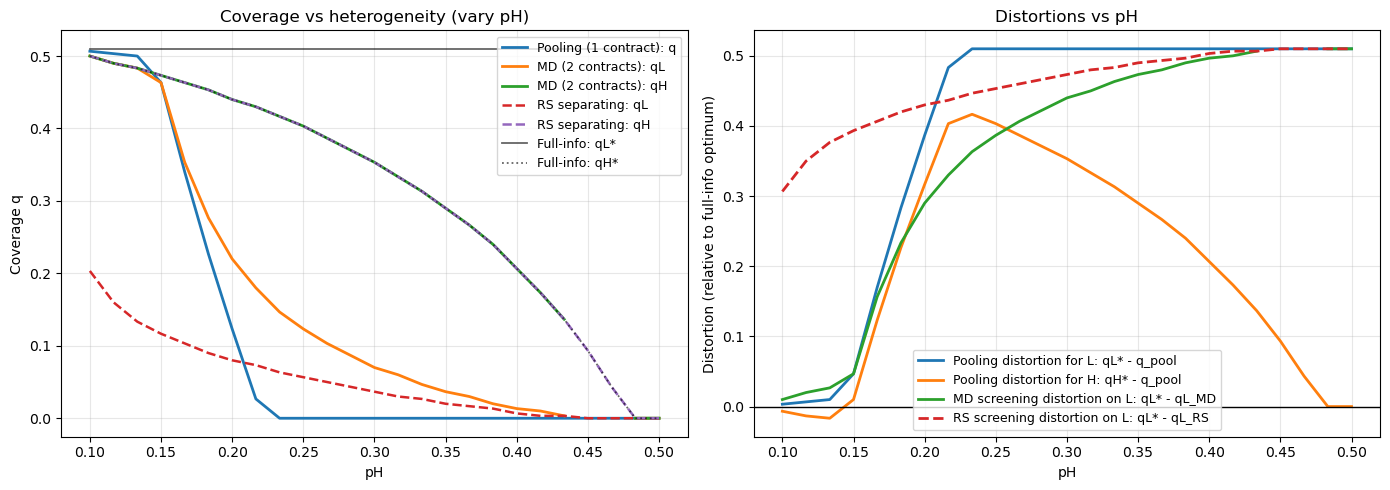

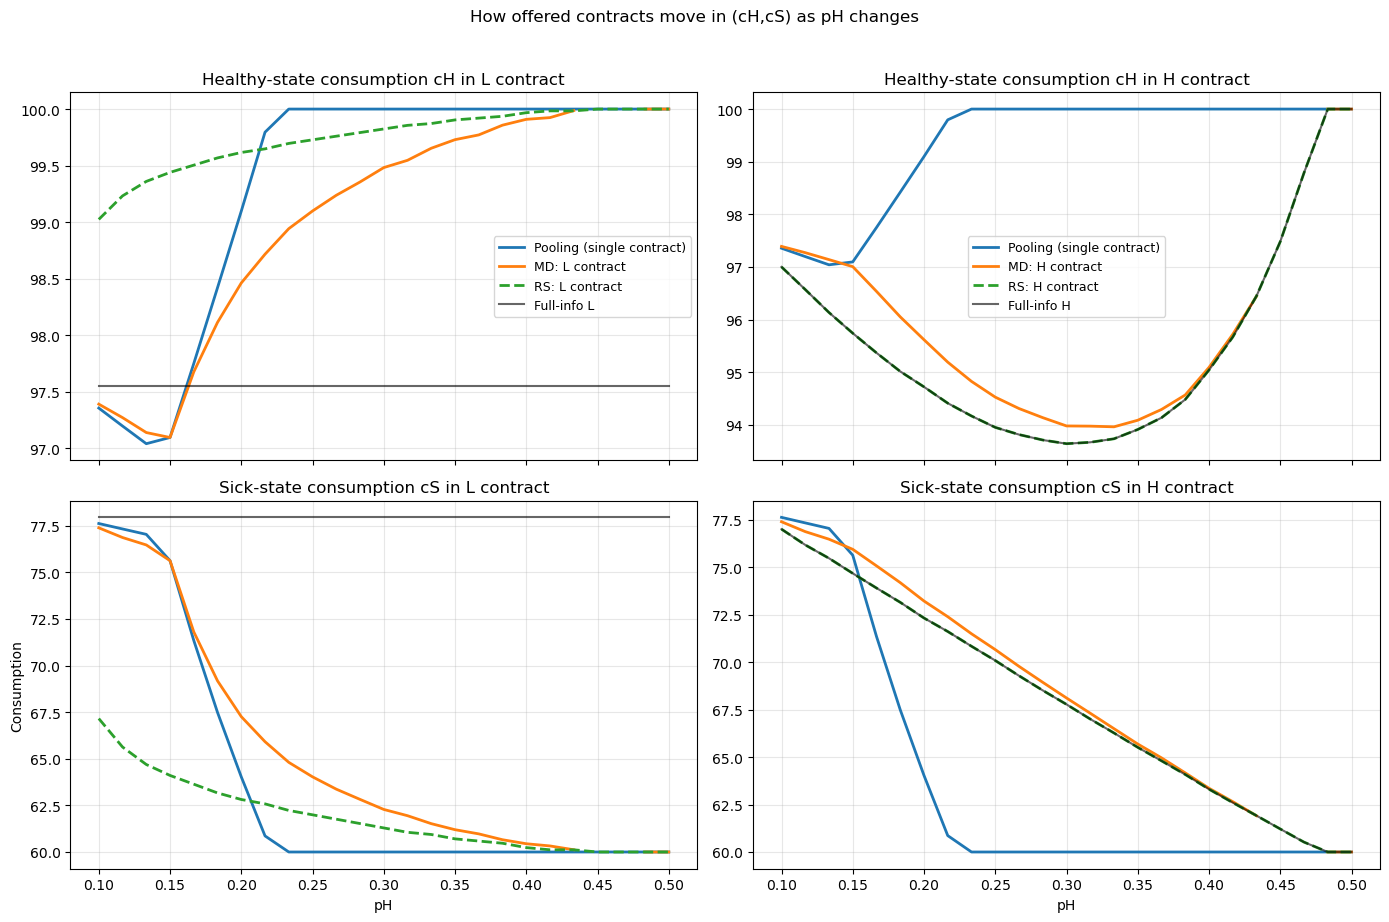

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# -----------------------------
# Baseline parameters
# -----------------------------
W = 100.0
Lloss = 40.0
pL = 0.08
lam = 0.35
alpha = 1.0
gamma = 2.0

# -----------------------------
# Preferences and primitives
# -----------------------------
def u(c, gamma):
    c = np.maximum(c, 1e-12)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(c)
    return (c ** (1 - gamma)) / (1 - gamma)

def EU(W, Lloss, p, q, pi, gamma):
    cH = W - pi
    cS = W - pi - (1 - q) * Lloss
    return (1 - p) * u(cH, gamma) + p * u(cS, gamma)

def EU0(W, Lloss, p, gamma):
    return (1 - p) * u(W, gamma) + p * u(W - Lloss, gamma)

def cost(Lloss, p, q, alpha):
    return (1 + alpha) * p * q * Lloss

def cons_from_contract(W, Lloss, q, pi):
    cH = W - pi
    cS = W - pi - (1 - q) * Lloss
    return cH, cS

# -----------------------------
# Full-info optimum q*(p)
# -----------------------------
def q_fullinfo_star(W, Lloss, p, alpha, gamma, q_grid):
    pi = cost(Lloss, p, q_grid, alpha)
    vals = (1 - p) * u(W - pi, gamma) + p * u(W - pi - (1 - q_grid) * Lloss, gamma)
    return q_grid[np.argmax(vals)]

def fullinfo_contract(W, Lloss, p, alpha, gamma, q_grid):
    q = q_fullinfo_star(W, Lloss, p, alpha, gamma, q_grid)
    pi = cost(Lloss, p, q, alpha)
    return {"q": q, "pi": pi}

# -----------------------------
# Best pooling (one contract), priced at pbar
# -----------------------------
def best_pooling(W, Lloss, pL, pH, lam, alpha, gamma, q_grid, require_IR=True):
    pbar = lam * pH + (1 - lam) * pL
    EU0L, EU0H = EU0(W, Lloss, pL, gamma), EU0(W, Lloss, pH, gamma)

    best = None
    for q in q_grid:
        pi = cost(Lloss, pbar, q, alpha)
        EUL = EU(W, Lloss, pL, q, pi, gamma)
        EUH = EU(W, Lloss, pH, q, pi, gamma)
        if require_IR and (EUL < EU0L - 1e-10 or EUH < EU0H - 1e-10):
            continue
        EUavg = (1 - lam) * EUL + lam * EUH
        if best is None or EUavg > best["EUavg"]:
            best = {"q": q, "pi": pi, "EUavg": EUavg}
    return best

# -----------------------------
# Solve premia given qL,qH using:
#  - IC_H binds
#  - aggregate break-even binds
# -----------------------------
def solve_premia_given_q_MD(W, Lloss, pL, pH, lam, alpha, gamma, qL, qH):
    CL = cost(Lloss, pL, qL, alpha)
    CH = cost(Lloss, pH, qH, alpha)
    cost_avg = (1 - lam) * CL + lam * CH

    def piH_from_piL(piL):
        return (cost_avg - (1 - lam) * piL) / lam

    def F(piL):
        piH = piH_from_piL(piL)
        return EU(W, Lloss, pH, qH, piH, gamma) - EU(W, Lloss, pH, qL, piL, gamma)

    piL_min = 0.0
    piL_max = min(W - 1e-8, W - (1 - qL) * Lloss - 1e-8)
    if piL_max <= piL_min:
        return None

    fmin, fmax = F(piL_min), F(piL_max)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return None

    piL = brentq(F, piL_min, piL_max, maxiter=200)
    piH = piH_from_piL(piL)

    if piH < 0 or piH > W - 1e-8 or piH > W - (1 - qH) * Lloss - 1e-8:
        return None

    return piL, piH

# -----------------------------
# FAST MD separating: impose "no distortion at top" => qH efficient
# then search only over qL
# -----------------------------
def best_separating_MD_top_nodist(W, Lloss, pL, pH, lam, alpha, gamma, q_grid):
    EU0L, EU0H = EU0(W, Lloss, pL, gamma), EU0(W, Lloss, pH, gamma)
    qH_star = q_fullinfo_star(W, Lloss, pH, alpha, gamma, q_grid)

    best = None
    for qL in q_grid:
        sol = solve_premia_given_q_MD(W, Lloss, pL, pH, lam, alpha, gamma, qL, qH_star)
        if sol is None:
            continue
        piL, piH = sol

        EUL_own = EU(W, Lloss, pL, qL, piL, gamma)
        EUH_own = EU(W, Lloss, pH, qH_star, piH, gamma)

        if EUL_own < EU0L - 1e-10 or EUH_own < EU0H - 1e-10:
            continue
        if EUL_own < EU(W, Lloss, pL, qH_star, piH, gamma) - 1e-10:
            continue

        EUavg = (1 - lam) * EUL_own + lam * EUH_own
        if best is None or EUavg > best["EUavg"]:
            best = {"qL": qL, "piL": piL, "qH": qH_star, "piH": piH, "EUavg": EUavg}
    return best

# -----------------------------
# RS separating (competitive-style approximation)
# -----------------------------
def RS_separating(W, Lloss, pL, pH, alpha, gamma, q_grid):
    bestH = None
    for qH in q_grid:
        piH = cost(Lloss, pH, qH, alpha)
        EUH = EU(W, Lloss, pH, qH, piH, gamma)
        if bestH is None or EUH > bestH["EUH"]:
            bestH = {"qH": qH, "piH": piH, "EUH": EUH}

    bestL = None
    EUH_at_H = bestH["EUH"]
    for qL in q_grid:
        piL = cost(Lloss, pL, qL, alpha)
        if EU(W, Lloss, pH, qL, piL, gamma) > EUH_at_H + 1e-10:
            continue
        EUL = EU(W, Lloss, pL, qL, piL, gamma)
        if bestL is None or EUL > bestL["EUL"]:
            bestL = {"qL": qL, "piL": piL, "EUL": EUL}

    return {"qL": bestL["qL"], "piL": bestL["piL"], "qH": bestH["qH"], "piH": bestH["piH"]}

# -----------------------------
# Plot 1: contract space with outcome points + indiff curves through Pool
# (keep yours; this is your existing one)
# -----------------------------
def plot_contract_space(W, Lloss, pL, pH, lam, alpha, gamma, pool, md, rs, title="Contract space"):
    qgrid = np.linspace(0, 1, 401)
    pbar = lam*pH + (1-lam)*pL

    def locus(p):
        pi = cost(Lloss, p, qgrid, alpha)
        cH = W - pi
        cS = W - pi - (1-qgrid)*Lloss
        return cH, cS

    cHL, cSL = locus(pL)
    cHH, cSH = locus(pH)
    cHB, cSB = locus(pbar)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(cHL, cSL, lw=2, label="Zero-profit if priced @ pL")
    ax.plot(cHH, cSH, lw=2, label="Zero-profit if priced @ pH")
    ax.plot(cHB, cSB, lw=2, ls="--", label="Zero-profit if priced @ pbar (pool)")

    def scatter(q, pi, label, dy=6):
        cH, cS = cons_from_contract(W, Lloss, q, pi)
        ax.scatter([cH],[cS], s=70)
        ax.annotate(label, (cH,cS), xytext=(6,dy), textcoords="offset points")

    scatter(pool["q"], pool["pi"], "Pool")
    scatter(md["qL"], md["piL"], "MD L", dy=6)
    scatter(md["qH"], md["piH"], "MD H", dy=-14)
    scatter(rs["qL"], rs["piL"], "RS L", dy=6)
    scatter(rs["qH"], rs["piH"], "RS H", dy=-14)

    # single-crossing illustration: indifference curves through pooling point
    cH_pool, cS_pool = cons_from_contract(W, Lloss, pool["q"], pool["pi"])
    cH_vals = np.linspace(min(cHL.min(), cHH.min())-2, W+2, 250)
    cS_vals = np.linspace(min(cSL.min(), cSH.min())-2, W+2, 250)
    CH, CS = np.meshgrid(cH_vals, cS_vals)

    EU_L_ref = (1-pL)*u(cH_pool,gamma) + pL*u(cS_pool,gamma)
    EU_H_ref = (1-pH)*u(cH_pool,gamma) + pH*u(cS_pool,gamma)
    EU_L_grid = (1-pL)*u(CH,gamma) + pL*u(CS,gamma)
    EU_H_grid = (1-pH)*u(CH,gamma) + pH*u(CS,gamma)

    ax.contour(CH, CS, EU_L_grid, levels=[EU_L_ref], colors=["C0"], linewidths=2)
    ax.contour(CH, CS, EU_H_grid, levels=[EU_H_ref], colors=["C1"], linewidths=2)

    ax.set_xlabel("cH (healthy consumption)")
    ax.set_ylabel("cS (sick consumption)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# -----------------------------
# Plot 2: q + distortions vs pH (your sweep)
# -----------------------------
def sweep_q_and_distortions():
    q_grid = np.linspace(0, 1, 301)
    pH_grid = np.linspace(0.10, 0.50, 25)

    qL_fb, qH_fb = [], []
    q_pool = []
    qL_md, qH_md = [], []
    qL_rs, qH_rs = [], []

    for pH in pH_grid:
        qLstar = q_fullinfo_star(W, Lloss, pL, alpha, gamma, q_grid)
        qHstar = q_fullinfo_star(W, Lloss, pH, alpha, gamma, q_grid)
        qL_fb.append(qLstar); qH_fb.append(qHstar)

        pool = best_pooling(W, Lloss, pL, pH, lam, alpha, gamma, q_grid, require_IR=True)
        q_pool.append(np.nan if pool is None else pool["q"])

        md = best_separating_MD_top_nodist(W, Lloss, pL, pH, lam, alpha, gamma, q_grid)
        qL_md.append(np.nan if md is None else md["qL"])
        qH_md.append(np.nan if md is None else md["qH"])

        rs = RS_separating(W, Lloss, pL, pH, alpha, gamma, q_grid)
        qL_rs.append(rs["qL"]); qH_rs.append(rs["qH"])

    qL_fb = np.array(qL_fb); qH_fb = np.array(qH_fb)
    q_pool = np.array(q_pool)
    qL_md = np.array(qL_md); qH_md = np.array(qH_md)
    qL_rs = np.array(qL_rs); qH_rs = np.array(qH_rs)

    d_pool_L = qL_fb - q_pool
    d_pool_H = qH_fb - q_pool
    d_md_L = qL_fb - qL_md
    d_rs_L = qL_fb - qL_rs

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(pH_grid, q_pool, label="Pooling (1 contract): q", lw=2)
    ax[0].plot(pH_grid, qL_md, label="MD (2 contracts): qL", lw=2)
    ax[0].plot(pH_grid, qH_md, label="MD (2 contracts): qH", lw=2)
    ax[0].plot(pH_grid, qL_rs, label="RS separating: qL", lw=1.8, ls="--")
    ax[0].plot(pH_grid, qH_rs, label="RS separating: qH", lw=1.8, ls="--")
    ax[0].plot(pH_grid, qL_fb, label="Full-info: qL*", lw=1.3, color="k", alpha=0.6)
    ax[0].plot(pH_grid, qH_fb, label="Full-info: qH*", lw=1.3, color="k", alpha=0.6, ls=":")
    ax[0].set_xlabel("pH")
    ax[0].set_ylabel("Coverage q")
    ax[0].set_title("Coverage vs heterogeneity (vary pH)")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(fontsize=9)

    ax[1].plot(pH_grid, d_pool_L, label="Pooling distortion for L: qL* - q_pool", lw=2)
    ax[1].plot(pH_grid, d_pool_H, label="Pooling distortion for H: qH* - q_pool", lw=2)
    ax[1].plot(pH_grid, d_md_L, label="MD screening distortion on L: qL* - qL_MD", lw=2)
    ax[1].plot(pH_grid, d_rs_L, label="RS screening distortion on L: qL* - qL_RS", lw=2, ls="--")
    ax[1].axhline(0, color="k", lw=1)
    ax[1].set_xlabel("pH")
    ax[1].set_ylabel("Distortion (relative to full-info optimum)")
    ax[1].set_title("Distortions vs pH")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot 3 (NEW): how cH and cS move as pH changes for each contract/regime
# -----------------------------
def sweep_consumption_by_regime():
    q_grid = np.linspace(0, 1, 301)
    pH_grid = np.linspace(0.10, 0.50, 25)

    # For each pH we will record:
    # - Pool: cH_pool, cS_pool (same for both types)
    # - MD menu: (cH_L, cS_L) and (cH_H, cS_H)
    # - RS menu: same
    # - Full-info: type-specific efficient points for L and H

    pool_cH, pool_cS = [], []
    md_L_cH, md_L_cS, md_H_cH, md_H_cS = [], [], [], []
    rs_L_cH, rs_L_cS, rs_H_cH, rs_H_cS = [], [], [], []
    fb_L_cH, fb_L_cS, fb_H_cH, fb_H_cS = [], [], [], []

    for pH in pH_grid:
        # full info
        fbL = fullinfo_contract(W, Lloss, pL, alpha, gamma, q_grid)
        fbH = fullinfo_contract(W, Lloss, pH, alpha, gamma, q_grid)
        cH, cS = cons_from_contract(W, Lloss, fbL["q"], fbL["pi"])
        fb_L_cH.append(cH); fb_L_cS.append(cS)
        cH, cS = cons_from_contract(W, Lloss, fbH["q"], fbH["pi"])
        fb_H_cH.append(cH); fb_H_cS.append(cS)

        # pooling
        pool = best_pooling(W, Lloss, pL, pH, lam, alpha, gamma, q_grid, require_IR=True)
        if pool is None:
            pool_cH.append(np.nan); pool_cS.append(np.nan)
        else:
            cH, cS = cons_from_contract(W, Lloss, pool["q"], pool["pi"])
            pool_cH.append(cH); pool_cS.append(cS)

        # MD
        md = best_separating_MD_top_nodist(W, Lloss, pL, pH, lam, alpha, gamma, q_grid)
        if md is None:
            md_L_cH.append(np.nan); md_L_cS.append(np.nan)
            md_H_cH.append(np.nan); md_H_cS.append(np.nan)
        else:
            cH, cS = cons_from_contract(W, Lloss, md["qL"], md["piL"])
            md_L_cH.append(cH); md_L_cS.append(cS)
            cH, cS = cons_from_contract(W, Lloss, md["qH"], md["piH"])
            md_H_cH.append(cH); md_H_cS.append(cS)

        # RS
        rs = RS_separating(W, Lloss, pL, pH, alpha, gamma, q_grid)
        cH, cS = cons_from_contract(W, Lloss, rs["qL"], rs["piL"])
        rs_L_cH.append(cH); rs_L_cS.append(cS)
        cH, cS = cons_from_contract(W, Lloss, rs["qH"], rs["piH"])
        rs_H_cH.append(cH); rs_H_cS.append(cS)

    pH_grid = np.array(pH_grid)

    fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

    # Low contract: cH
    ax[0,0].plot(pH_grid, pool_cH, label="Pooling (single contract)", lw=2)
    ax[0,0].plot(pH_grid, md_L_cH, label="MD: L contract", lw=2)
    ax[0,0].plot(pH_grid, rs_L_cH, label="RS: L contract", lw=2, ls="--")
    ax[0,0].plot(pH_grid, fb_L_cH, label="Full-info L", lw=1.5, color="k", alpha=0.6)
    ax[0,0].set_title("Healthy-state consumption cH in L contract")
    ax[0,0].grid(True, alpha=0.3)
    ax[0,0].legend(fontsize=9)

    # Low contract: cS
    ax[1,0].plot(pH_grid, pool_cS, label="Pooling (single contract)", lw=2)
    ax[1,0].plot(pH_grid, md_L_cS, label="MD: L contract", lw=2)
    ax[1,0].plot(pH_grid, rs_L_cS, label="RS: L contract", lw=2, ls="--")
    ax[1,0].plot(pH_grid, fb_L_cS, label="Full-info L", lw=1.5, color="k", alpha=0.6)
    ax[1,0].set_title("Sick-state consumption cS in L contract")
    ax[1,0].grid(True, alpha=0.3)
    ax[1,0].set_xlabel("pH")
    ax[1,0].set_ylabel("Consumption")

    # High contract: cH
    ax[0,1].plot(pH_grid, pool_cH, label="Pooling (single contract)", lw=2)
    ax[0,1].plot(pH_grid, md_H_cH, label="MD: H contract", lw=2)
    ax[0,1].plot(pH_grid, rs_H_cH, label="RS: H contract", lw=2, ls="--")
    ax[0,1].plot(pH_grid, fb_H_cH, label="Full-info H", lw=1.5, color="k", alpha=0.6)
    ax[0,1].set_title("Healthy-state consumption cH in H contract")
    ax[0,1].grid(True, alpha=0.3)
    ax[0,1].legend(fontsize=9)

    # High contract: cS
    ax[1,1].plot(pH_grid, pool_cS, label="Pooling (single contract)", lw=2)
    ax[1,1].plot(pH_grid, md_H_cS, label="MD: H contract", lw=2)
    ax[1,1].plot(pH_grid, rs_H_cS, label="RS: H contract", lw=2, ls="--")
    ax[1,1].plot(pH_grid, fb_H_cS, label="Full-info H", lw=1.5, color="k", alpha=0.6)
    ax[1,1].set_title("Sick-state consumption cS in H contract")
    ax[1,1].grid(True, alpha=0.3)
    ax[1,1].set_xlabel("pH")

    plt.suptitle("How offered contracts move in (cH,cS) as pH changes", y=1.02)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run all three plot sets
# -----------------------------
# (A) Contract space at one pH
pH0 = 0.30
q_grid0 = np.linspace(0, 1, 301)
pool0 = best_pooling(W, Lloss, pL, pH0, lam, alpha, gamma, q_grid0, require_IR=True)
md0   = best_separating_MD_top_nodist(W, Lloss, pL, pH0, lam, alpha, gamma, q_grid0)
rs0   = RS_separating(W, Lloss, pL, pH0, alpha, gamma, q_grid0)

plot_contract_space(W, Lloss, pL, pH0, lam, alpha, gamma, pool0, md0, rs0,
                    title=f"Contract space at pH={pH0:.2f}, pbar={lam*pH0+(1-lam)*pL:.3f}")

# (B) q + distortions sweep
sweep_q_and_distortions()

# (C) NEW: (cH,cS) sweep
sweep_consumption_by_regime()

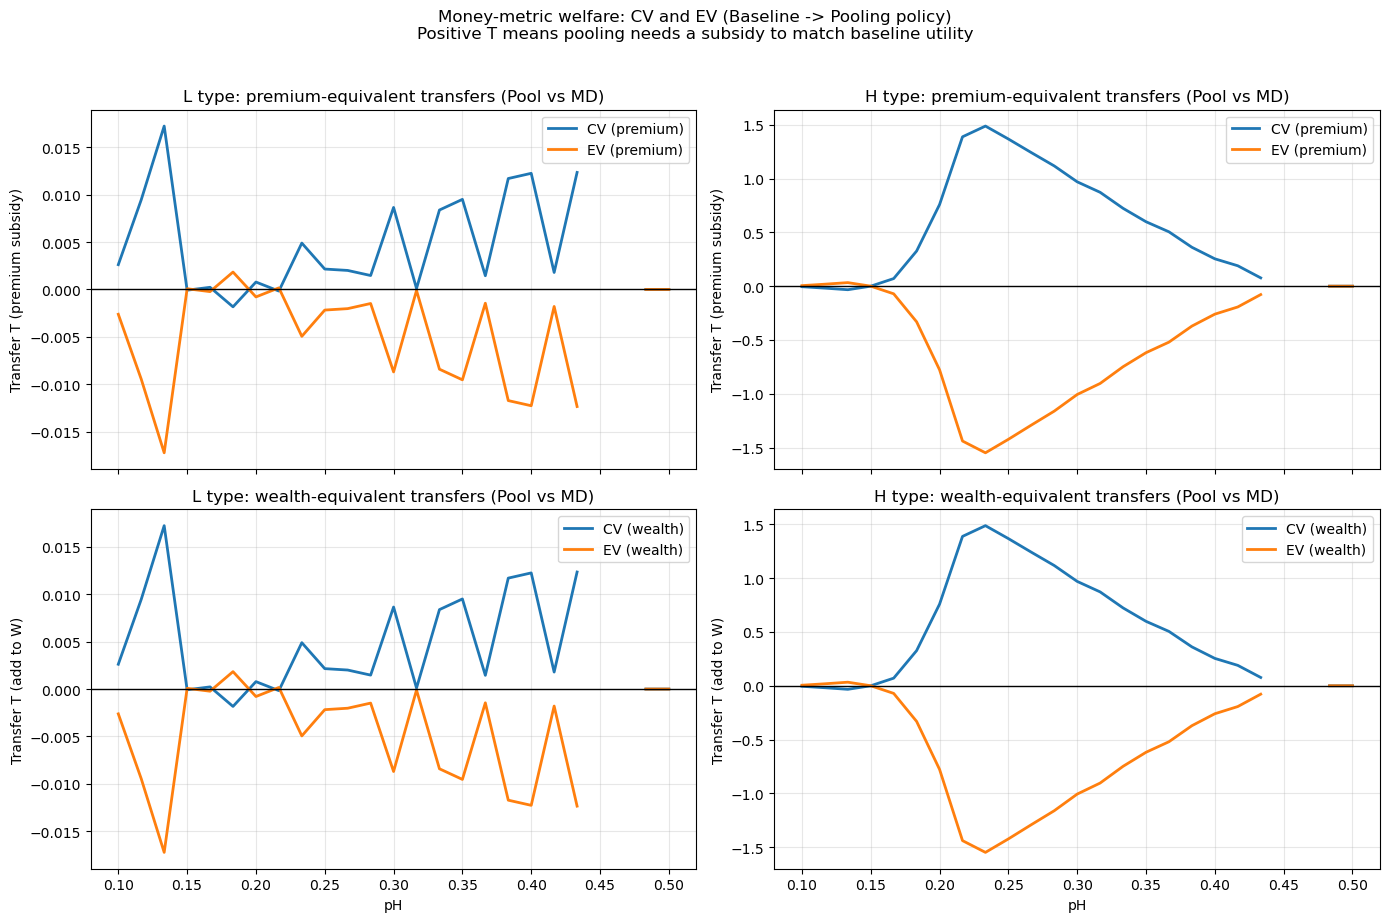

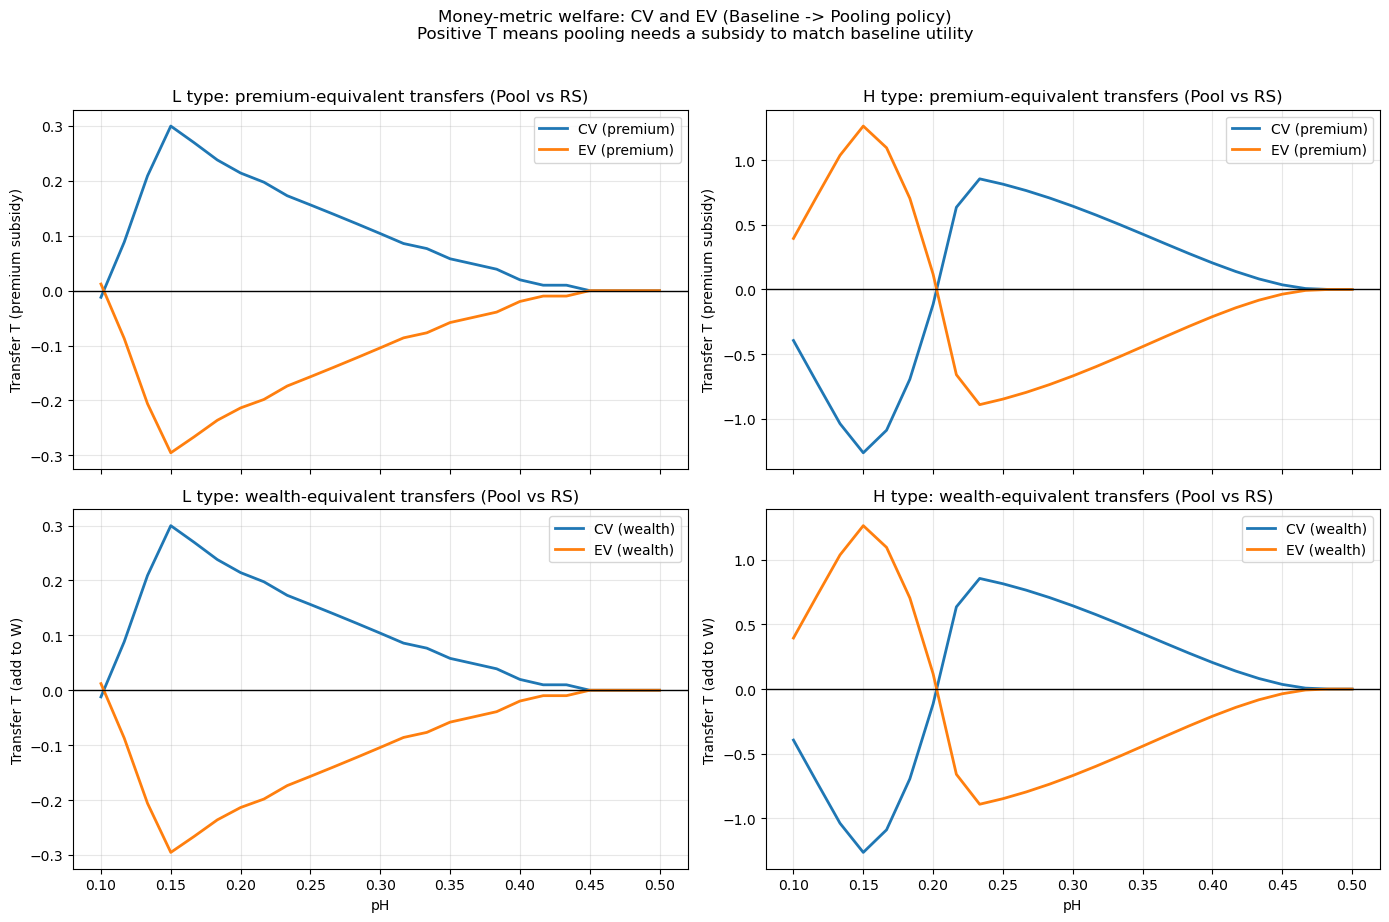

In [2]:


# -----------------------------
# Money-metric welfare: CV and EV
# -----------------------------
def feasible_T_bounds_premium(W, Lloss, q, pi):
    """
    For premium shift: new premium = pi - T.
    Require cH>0 and cS>0 => pi - T < W and pi - T < W-(1-q)Lloss.
    That implies T > pi - (W-(1-q)Lloss). No real upper bound (negative premium is allowed),
    but we cap for numerical stability.
    """
    lower = pi - (W - (1 - q) * Lloss) + 1e-8  # ensures cS>0
    upper = pi + W  # allows big negative premium but bounded
    return lower, upper

def premium_transfer_to_match(W, Lloss, p, gamma, contract_from, target_EU):
    """
    Find T such that EU(contract_from with premium shifted by T) = target_EU,
    where shift means: premium becomes (pi - T).
    T>0 means you lower the premium / subsidize the person.
    """
    q, pi = contract_from["q"], contract_from["pi"]

    Tmin, Tmax = feasible_T_bounds_premium(W, Lloss, q, pi)

    def f(T):
        return EU(W, Lloss, p, q, pi - T, gamma) - target_EU

    fmin, fmax = f(Tmin), f(Tmax)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return None
    return brentq(f, Tmin, Tmax, maxiter=500)

def CV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    """
    Compensating variation (premium metric) for moving from baseline -> policy:
    amount T you must GIVE under policy (as a premium subsidy) to reach baseline utility.
    Solve: EU(policy with pi - T) = EU(baseline).
    """
    target = EU(W, Lloss, p, baseline_contract["q"], baseline_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, policy_contract, target)

def EV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    """
    Equivalent variation (premium metric) for moving from baseline -> policy:
    amount T you must GIVE under baseline to reach policy utility.
    Solve: EU(baseline with pi - T) = EU(policy).
    """
    target = EU(W, Lloss, p, policy_contract["q"], policy_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, baseline_contract, target)


def wealth_transfer_to_match(W, Lloss, p, gamma, contract_from, target_EU):
    """
    Find T such that EU(W+T, contract_from) = target_EU.
    """
    q, pi = contract_from["q"], contract_from["pi"]

    # Ensure positive consumption in both states under W+T
    Tmin = -W + 1e-6
    Tmax =  W  # you can expand if needed

    def f(T):
        return EU(W + T, Lloss, p, q, pi, gamma) - target_EU

    fmin, fmax = f(Tmin), f(Tmax)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return None
    return brentq(f, Tmin, Tmax, maxiter=500)

def CV_wealth(W, Lloss, p, gamma, baseline_contract, policy_contract):
    """
    CV (wealth metric): give T under policy so that EU(policy, W+T)=EU(baseline, W).
    """
    target = EU(W, Lloss, p, baseline_contract["q"], baseline_contract["pi"], gamma)
    return wealth_transfer_to_match(W, Lloss, p, gamma, policy_contract, target)

def EV_wealth(W, Lloss, p, gamma, baseline_contract, policy_contract):
    """
    EV (wealth metric): give T under baseline so that EU(baseline, W+T)=EU(policy, W).
    """
    target = EU(W, Lloss, p, policy_contract["q"], policy_contract["pi"], gamma)
    return wealth_transfer_to_match(W, Lloss, p, gamma, baseline_contract, target)

def sweep_CV_EV_transfers_vs_pH(compare_to="MD"):
    """
    compare_to: "MD" or "RS" (baseline).
    Plots premium-based and wealth-based CV/EV for L and H.
    """
    q_grid = np.linspace(0, 1, 301)
    pH_grid = np.linspace(0.10, 0.50, 25)

    CVp_L, EVp_L, CVp_H, EVp_H = [], [], [], []
    CVw_L, EVw_L, CVw_H, EVw_H = [], [], [], []

    for pH in pH_grid:
        pool = best_pooling(W, Lloss, pL, pH, lam, alpha, gamma, q_grid, require_IR=True)
        if pool is None:
            # fill missing
            CVp_L.append(np.nan); EVp_L.append(np.nan); CVp_H.append(np.nan); EVp_H.append(np.nan)
            CVw_L.append(np.nan); EVw_L.append(np.nan); CVw_H.append(np.nan); EVw_H.append(np.nan)
            continue
        pool_contract = {"q": pool["q"], "pi": pool["pi"]}

        if compare_to == "MD":
            md = best_separating_MD_top_nodist(W, Lloss, pL, pH, lam, alpha, gamma, q_grid)
            if md is None:
                CVp_L.append(np.nan); EVp_L.append(np.nan); CVp_H.append(np.nan); EVp_H.append(np.nan)
                CVw_L.append(np.nan); EVw_L.append(np.nan); CVw_H.append(np.nan); EVw_H.append(np.nan)
                continue
            base_L = {"q": md["qL"], "pi": md["piL"]}
            base_H = {"q": md["qH"], "pi": md["piH"]}
        elif compare_to == "RS":
            rs = RS_separating(W, Lloss, pL, pH, alpha, gamma, q_grid)
            base_L = {"q": rs["qL"], "pi": rs["piL"]}
            base_H = {"q": rs["qH"], "pi": rs["piH"]}
        else:
            raise ValueError("compare_to must be 'MD' or 'RS'")

        # Baseline -> Policy means: baseline is MD/RS, policy is Pooling
        # Compute for L:
        CVp_L.append(CV_premium(W, Lloss, pL, gamma, base_L, pool_contract))
        EVp_L.append(EV_premium(W, Lloss, pL, gamma, base_L, pool_contract))
        CVw_L.append(CV_wealth(W, Lloss, pL, gamma, base_L, pool_contract))
        EVw_L.append(EV_wealth(W, Lloss, pL, gamma, base_L, pool_contract))

        # For H:
        CVp_H.append(CV_premium(W, Lloss, pH, gamma, base_H, pool_contract))
        EVp_H.append(EV_premium(W, Lloss, pH, gamma, base_H, pool_contract))
        CVw_H.append(CV_wealth(W, Lloss, pH, gamma, base_H, pool_contract))
        EVw_H.append(EV_wealth(W, Lloss, pH, gamma, base_H, pool_contract))

    pH_grid = np.array(pH_grid)

    fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

    ax[0,0].plot(pH_grid, CVp_L, lw=2, label="CV (premium)")
    ax[0,0].plot(pH_grid, EVp_L, lw=2, label="EV (premium)")
    ax[0,0].axhline(0, color="k", lw=1)
    ax[0,0].set_title(f"L type: premium-equivalent transfers (Pool vs {compare_to})")
    ax[0,0].set_ylabel("Transfer T (premium subsidy)")
    ax[0,0].grid(True, alpha=0.3)
    ax[0,0].legend()

    ax[1,0].plot(pH_grid, CVw_L, lw=2, label="CV (wealth)")
    ax[1,0].plot(pH_grid, EVw_L, lw=2, label="EV (wealth)")
    ax[1,0].axhline(0, color="k", lw=1)
    ax[1,0].set_title(f"L type: wealth-equivalent transfers (Pool vs {compare_to})")
    ax[1,0].set_xlabel("pH")
    ax[1,0].set_ylabel("Transfer T (add to W)")
    ax[1,0].grid(True, alpha=0.3)
    ax[1,0].legend()

    ax[0,1].plot(pH_grid, CVp_H, lw=2, label="CV (premium)")
    ax[0,1].plot(pH_grid, EVp_H, lw=2, label="EV (premium)")
    ax[0,1].axhline(0, color="k", lw=1)
    ax[0,1].set_title(f"H type: premium-equivalent transfers (Pool vs {compare_to})")
    ax[0,1].set_ylabel("Transfer T (premium subsidy)")
    ax[0,1].grid(True, alpha=0.3)
    ax[0,1].legend()

    ax[1,1].plot(pH_grid, CVw_H, lw=2, label="CV (wealth)")
    ax[1,1].plot(pH_grid, EVw_H, lw=2, label="EV (wealth)")
    ax[1,1].axhline(0, color="k", lw=1)
    ax[1,1].set_title(f"H type: wealth-equivalent transfers (Pool vs {compare_to})")
    ax[1,1].set_xlabel("pH")
    ax[1,1].set_ylabel("Transfer T (add to W)")
    ax[1,1].grid(True, alpha=0.3)
    ax[1,1].legend()

    plt.suptitle("Money-metric welfare: CV and EV (Baseline -> Pooling policy)\nPositive T means pooling needs a subsidy to match baseline utility", y=1.02)
    plt.tight_layout()
    plt.show()

# New:
sweep_CV_EV_transfers_vs_pH(compare_to="MD")
# optionally:
sweep_CV_EV_transfers_vs_pH(compare_to="RS")